In [2]:
#main file
import os
import math
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from torch.utils.data import Dataset, DataLoader


import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
from tqdm.notebook import tqdm
import numpy as np

from torch.utils.data import DataLoader
from torchvision.utils import save_image
from torchvision.io import read_image
from torchvision.transforms import Resize
from torchvision.transforms import Compose, ToTensor, Lambda, Pad
from PIL import Image
nn = torch.nn
F = nn.functional

In [3]:
class FaceDetectionDataset(torch.utils.data.Dataset):
    def __init__(self, train=True): 
        self.file_names = []
        self.samples = []
        split = 'train' if train else 'test'
        with open(f'FDDB-folds/FDDB-fold-01.txt','r') as f:
            entry = f.readline()
            while entry:
                self.file_names.append(entry.strip())
                entry = f.readline()
        
    def __len__(self): 
        ### returns the number of items in the dataset, nice and simple
        return len(self.file_names)

    def __getitem__(self, idx): 
        name = self.file_names[idx]
        ### of the form (x, y) the values are scaled by 255 and returned as type float
        sample = (read_image(f'{name}.jpg')/255.)
        return sample 
        
    def get_plottable(self, idx): 
        ### Same deal as before but this time the images are permuted and not scaled
        name = self.file_names[idx]
        sample = read_image(f'{name}.jpg').permute(1,2,0) 
        return sample 

    def get_plottable2(self, idx): 
        ### Same deal as before but this time the images are permuted and not scaled
        name = self.file_names[idx]
        sample = read_image(f'{name}.jpg').permute(1,2,0) 
        return sample 

    def get_box(self, idx): 
        ### Same deal as before but this time the images are permuted and not scaled
        
        for i in range(len(self.data[idx])):
            rect = patches.Rectangle((self.data[idx][i][0], self.data[idx][i][1]), self.data[idx][i][2], self.data[idx][i][3], linewidth=1, edgecolor='r', facecolor='none')
            plt.gca().add_patch(rect)
        return rect 



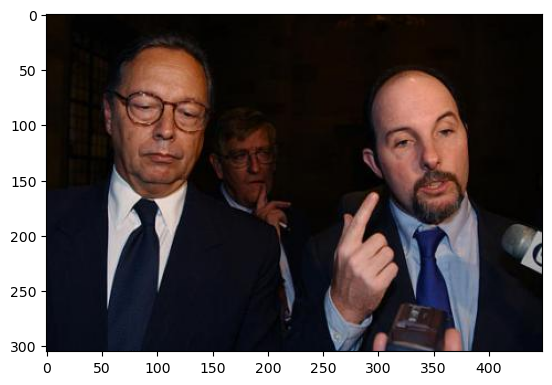

In [4]:
images = FaceDetectionDataset()
image = images.get_plottable(1)
plt.imshow(image)

In [5]:

def getEllipses(path, image_dims, adjustments, resize):
    boxes = []
    num_faces = []
    i = 0

    with open(path,'r') as f:
            entry = f.readline() #discard the first line
            while entry:
                #read number of lines to process
                n = int(f.readline().strip())
                num_faces.append(n)
                box_format = []
                several_boxes = []
                width = image_dims[i][0]
                height = image_dims[i][1]
                left_adjustment = adjustments[i][1]
                vertical_adjustment = adjustments[i][0]
                #print(i, " ", width, " ", height)
                for _ in range(n):
                    line = f.readline().strip()
                    ellipse = []
                    ellipse = line.split()
                    box = getBox(ellipse)
                    #print("original box ", box)
                    if resize:
                        box[0] += left_adjustment
                        box[1] += vertical_adjustment
                    several_boxes.append(box)
                   # print("new box ", box)
                boxes.append(torch.stack(several_boxes))
                entry = f.readline()
                i += 1
    return boxes, num_faces
            
    
def getBox(ellipse):
    # Extract ellipse parameters
    major_axis_radius = float(ellipse[0])  # Extract from the ellipse annotation
    minor_axis_radius = float(ellipse[1]) # Extract from the ellipse annotation
    angle = float(ellipse[2])             # Extract from the ellipse annotation
    center_x = float(ellipse[3])           # Extract from the ellipse annotation
    center_y = float(ellipse[4]) 
    detection_score = float(ellipse[5])

    # Calculate the coordinates of the extreme points of the ellipse
    cos_angle = math.cos(angle)
    sin_angle = math.sin(angle)

    # Calculate the coordinates of the major and minor axis endpoints
    major_axis_x1 = center_x + major_axis_radius * cos_angle
    major_axis_y1 = center_y + major_axis_radius * sin_angle
    major_axis_x2 = center_x - major_axis_radius * cos_angle
    major_axis_y2 = center_y - major_axis_radius * sin_angle

    minor_axis_x1 = center_x - minor_axis_radius * sin_angle
    minor_axis_y1 = center_y + minor_axis_radius * cos_angle
    minor_axis_x2 = center_x + minor_axis_radius * sin_angle
    minor_axis_y2 = center_y - minor_axis_radius * cos_angle

    # Find the minimum and maximum coordinates
    left_x = min(major_axis_x1, major_axis_x2, minor_axis_x1, minor_axis_x2)
    right_x = max(major_axis_x1, major_axis_x2, minor_axis_x1, minor_axis_x2)
    top_y = min(major_axis_y1, major_axis_y2, minor_axis_y1, minor_axis_y2)
    bottom_y = max(major_axis_y1, major_axis_y2, minor_axis_y1, minor_axis_y2)

    # Calculate the width and height of the bounding box
    width = right_x - left_x
    height = bottom_y - top_y

    # Format the bounding box as <left_x top_y width height detection_score>
    bbox_format = torch.tensor([left_x, top_y, width, height, detection_score])

    return(bbox_format)


In [1]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms
import torchvision.transforms

#target width and height must be larger than largest image
target_width = 512 
target_height= 512

def get_Data(path):
    image_dims = np.empty((5000,2)) #dummy tensor
    
    #FDDB-folds/FDDB-fold-01.txt
    with open(f'{path}.txt','r') as f:
                entry = f.readline()
                i = 0
                while entry:
                    file_name = entry.strip()
                    image = read_image(f'{file_name}.jpg').permute(1,2,0) 
                    image_dims[i][0] = image.shape[0]
                    image_dims[i][1] = image.shape[1]
                    i += 1
                    entry = f.readline()
    
    def resize(target_height, target_width, current_height, current_width):
        v_padding = (target_height - current_height) / 2
        h_padding = (target_width - current_width) / 2
        
        l_pad = h_padding if h_padding % 1 == 0 else h_padding+0.5
        t_pad = v_padding if v_padding % 1 == 0 else v_padding+0.5
        r_pad = h_padding if h_padding % 1 == 0 else h_padding-0.5
        b_pad = v_padding if v_padding % 1 == 0 else v_padding-0.5
        return (int(l_pad), int(t_pad), int(r_pad), int(b_pad))
    
        
    samples = []
    transformation_adjustments = np.empty((512,2)) #dummy tensor

    with open(f'{path}.txt','r') as f:
                entry = f.readline()
                i = 0
    
                while entry:
                    file_name = entry.strip()
                    image = read_image(f'{file_name}.jpg').permute(1,2,0)
                    padding = resize(target_height, target_width, image.shape[0], image.shape[1])
                    transformation_adjustments[i][0] = padding[1]
                    transformation_adjustments[i][1] = padding[0]
                    t_img = torchvision.transforms.functional.pad(image.permute(2, 0, 1), padding)
                    image = t_img.permute(1, 2, 0)
                    samples.append(image)
                    entry = f.readline()
                    i += 1
    
    labels, num_faces = getEllipses(f'{path}-ellipseList.txt', image_dims, transformation_adjustments, True)
    
    i=0
    
    #for image in samples:
     #   if image.shape != (target_width, target_height, 3):  
     #       del samples[i]
     #       del labels[i]
     #       del num_faces[i]
     #   i = i + 1

    for image in samples:
        if image.shape != (target_width, target_height, 3):
            del samples[i]
            del labels[i]
            del num_faces[i]
        i = i + 1
        
    return samples, labels, num_faces

    


class OurDataset(Dataset):
    def __init__(self, samples, labels, num_faces):
        self.samples = samples
        #self.max_label_length = max([len(label) for label in labels])
        self.max_label_length = max([label.shape[0] for label in labels])
        self.labels = [torch.cat((label, torch.zeros(self.max_label_length - label.shape[0], label.shape[1], 
                                        dtype=label.dtype)), dim=0) for label in labels]
 
        self.num_faces = [torch.tensor(num_faces[i]).unsqueeze(-1) for i in range(len(num_faces))]

    
    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx].clone().detach()
        label = self.labels[idx].clone().detach()
        num_faces = self.num_faces[idx].clone().detach()
        return sample, label, num_faces

def get_Rect(label):
    for i in range(len(label)):
        rect = patches.Rectangle((label[i][0], label[i][1]), label[i][2], label[i][3], linewidth=1, edgecolor='r', facecolor='none')
        plt.gca().add_patch(rect)
    return _


def get_labeled_sample(data):
    plt.imshow(data[0])
    get_Rect(data[1])
    
#dataset = OurDataset(samples, labels, num_faces)
#get_labeled_sample(dataset[1]) #Change numbet here to get a different image

#for i in range (0, len(samples)):
    #print(samples[i].shape)

#74 and 278 of shape 500x500x1 for some reason!!!!!!
#Proof beneath

#image = read_image(f'2002/07/22/big/img_725.jpg').permute(1,2,0)
#print(image.shape)
#image = read_image(f'2002/08/14/big/img_726.jpg').permute(1,2,0)
#print(image.shape)

#Can be used to check dims of labels and sampes in the dataset
#i = 0
#for label in dataset.labels:
#    if label.shape != (dataset.max_label_length, 5):
#        print(i, " ", label.shape)
#    i = i+1
#i=0
#for image in dataset.samples:
 #   if image.shape != (target_width, target_height, 3):
 #       print(i, " ", image.shape)
 #   i = i + 1


In [2]:
samples, labels, num_faces = get_Data("FDDB-folds/FDDB-fold-01")
samples2, labels2, num_faces2 = get_Data("FDDB-folds/FDDB-fold-02")
samples3, labels3, num_faces3 = get_Data("FDDB-folds/FDDB-fold-03")
samples4, labels4, num_faces4 = get_Data("FDDB-folds/FDDB-fold-04")
samples5, labels5, num_faces5 = get_Data("FDDB-folds/FDDB-fold-05")
samples6, labels6, num_faces6 = get_Data("FDDB-folds/FDDB-fold-06")
samples7, labels7, num_faces7 = get_Data("FDDB-folds/FDDB-fold-07")
samples8, labels8, num_faces8 = get_Data("FDDB-folds/FDDB-fold-08")
samples9, labels9, num_faces9 = get_Data("FDDB-folds/FDDB-fold-09")
samples10, labels10, num_faces10 = get_Data("FDDB-folds/FDDB-fold-10")
samples_list = [samples2, samples3, samples4, samples5, samples6, samples7, samples8, samples9, samples10]
labels_list = [labels2, labels3, labels4, labels5, labels6, labels7, labels8, labels9, labels10]
num_faces_list = [num_faces2, num_faces3, num_faces4, num_faces5, num_faces6, num_faces7, num_faces8, num_faces9, num_faces10]





for i in range(0,8):
    samples.extend(samples_list[i])
    labels.extend(labels_list[i])
    num_faces.extend(num_faces_list[i])




dataset = OurDataset(samples, labels, num_faces)

print(len(dataset.samples))
print(len(dataset.labels))
print(len(dataset.num_faces))


get_labeled_sample(dataset[1]) #Change numbet here to get a different image
print("Number of samples in the dataset: ", len(dataset))




NameError: name 'np' is not defined

In [9]:
"""
i = 0
for image in dataset.samples:
    if image.shape != (target_width, target_height, 3):
        print(i, " ", image.shape)
    i = i + 1




"""

In [10]:
#print(dataset.max_label_length)

10
